In [ ]:
################################# Libraries #################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
print("Βιβλιοθήκες φορτώθηκαν. Έτοιμοι για την προεπεξεργασία των 5G δεδομένων.")

Βιβλιοθήκες φορτώθηκαν. Έτοιμοι για την προεπεξεργασία των 5G δεδομένων.


In [ ]:
# Φόρτωση
train_df = pd.read_csv('/Users/antonistsipoulakos/Downloads/UNSW_NB15_training-set(in).csv')
test_df = pd.read_csv('/Users/antonistsipoulakos/Downloads/UNSW_NB15_testing-set(in).csv')

print(f" Αρχικό μέγεθος Train: {train_df.shape}")

# Καθαρισμός βάσει λογικής (Βήμα 2 εκφώνησης)
# Διαγράφουμε το 'id' (αύξων αριθμός) και το 'attack_cat' (λεπτομέρειες επίθεσης) 
# γιατί κάνουμε Δυαδική Κατηγοριοποίηση (Normal vs Attack).
train_df = train_df.drop(['id', 'attack_cat'], axis=1)
test_df = test_df.drop(['id', 'attack_cat'], axis=1)

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(" Διαγράφηκαν οι στήλες 'id' και 'attack_cat' ως μη σχετικές με τη δυαδική πρόβλεψη.")
print(f" Διαχωρισμός ολοκληρώθηκε. Στόχος (Label): 0 = Normal, 1 = Attack.")

📊 Αρχικό μέγεθος Train: (175341, 45)
💡 Διαγράφηκαν οι στήλες 'id' και 'attack_cat' ως μη σχετικές με τη δυαδική πρόβλεψη.
✅ Διαχωρισμός ολοκληρώθηκε. Στόχος (Label): 0 = Normal, 1 = Attack.


In [ ]:
print(" Μετατροπή ποιοτικών χαρακτηριστικών (proto, service, state) σε Dummy variables...")
categorical_cols = ['proto', 'service', 'state']
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Ευθυγράμμιση: Αν το Test έχει λιγότερα πρωτόκολλα από το Train, γεμίζουμε με 0.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0) 

print(f" Μετά τα Dummies, οι στήλες αυξήθηκαν σε: {X_train.shape[1]}")

print(" Εφαρμογή Min-Max Scaling στο διάστημα [0, 1]...")
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f" Η κανονικοποίηση ολοκληρώθηκε. Ελάχιστο: {X_train.min().min()}, Μέγιστο: {X_train.max().max()}")

⏳ Μετατροπή ποιοτικών χαρακτηριστικών (proto, service, state) σε Dummy variables...
💡 Μετά τα Dummies, οι στήλες αυξήθηκαν σε: 194
⏳ Εφαρμογή Min-Max Scaling στο διάστημα [0, 1]...
✅ Η κανονικοποίηση ολοκληρώθηκε. Ελάχιστο: 0.0, Μέγιστο: 1.0000000000000002


In [ ]:
def objective(trial):
    # Παράμετροι που ζητάει η εκφώνηση (eta/learning_rate, gamma, max_depth)
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**param)
    
    # 10-fold Cross Validation (Απαίτηση εκφώνησης)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    return np.mean(scores)

print(" Έναρξη βελτιστοποίησης υπερπαραμέτρων (Optuna Tuning)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # Μπορείς να το κάνεις 20 ή 30 για την τελική αναφορά

print("\n Tuning Ολοκληρώθηκε!")
print(f"Καλύτερες Παράμετροι: {study.best_params}")
print(f"Καλύτερη Ακρίβεια στο Train (CV Score): {study.best_value:.4f}")

# Εκπαίδευση τελικού μοντέλου
print(" Εκπαίδευση τελικού XGBoost με τις βέλτιστες παραμέτρους...")
final_xgb_model = xgb.XGBClassifier(**{**study.best_params, 'objective': 'binary:logistic', 'eval_metric': 'logloss'})
final_xgb_model.fit(X_train, y_train)
print(" Το μοντέλο εκπαιδεύτηκε και είναι έτοιμο για αξιολόγηση.")

[I 2026-03-26 18:26:28,191] A new study created in memory with name: no-name-6f92e331-3d48-47b0-8e4b-d7400818c882


🚀 Έναρξη βελτιστοποίησης υπερπαραμέτρων (Optuna Tuning)...


[I 2026-03-26 18:26:40,865] Trial 0 finished with value: 0.954403123879829 and parameters: {'learning_rate': 0.03835568116680996, 'max_depth': 8, 'gamma': 0.27304885250857036, 'n_estimators': 189}. Best is trial 0 with value: 0.954403123879829.
[I 2026-03-26 18:26:50,270] Trial 1 finished with value: 0.9353317270037154 and parameters: {'learning_rate': 0.01492868381031954, 'max_depth': 4, 'gamma': 0.7503216537356879, 'n_estimators': 194}. Best is trial 0 with value: 0.954403123879829.
[I 2026-03-26 18:26:59,342] Trial 2 finished with value: 0.9597584176267713 and parameters: {'learning_rate': 0.1451594083640376, 'max_depth': 7, 'gamma': 0.7705210398356503, 'n_estimators': 179}. Best is trial 2 with value: 0.9597584176267713.
[I 2026-03-26 18:27:04,386] Trial 3 finished with value: 0.9351948507293777 and parameters: {'learning_rate': 0.030582627390680232, 'max_depth': 4, 'gamma': 0.24139513942569368, 'n_estimators': 75}. Best is trial 2 with value: 0.9597584176267713.
[I 2026-03-26 18:2


🏆 Tuning Ολοκληρώθηκε!
Καλύτερες Παράμετροι: {'learning_rate': 0.1451594083640376, 'max_depth': 7, 'gamma': 0.7705210398356503, 'n_estimators': 179}
Καλύτερη Ακρίβεια στο Train (CV Score): 0.9598
⏳ Εκπαίδευση τελικού XGBoost με τις βέλτιστες παραμέτρους...
✅ Το μοντέλο εκπαιδεύτηκε και είναι έτοιμο για αξιολόγηση.


⏳ Αξιολόγηση μοντέλου στο Test Set (Αόρατα δεδομένα)...

       ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ XGBOOST
📈 Accuracy:  87.54% (Συνολική ορθότητα)
🎯 Precision: 0.8236 (Πόσο έγκυρος είναι ο συναγερμός επίθεσης)
🔍 Recall:    0.9845 (Πόσες από τις πραγματικές επιθέσεις βρήκαμε)
⚖️  F1-Score:  0.8969 (Ισορροπία Precision/Recall)
🛡️  ROC AUC:   0.9839 (Ικανότητα διαχωρισμού normal/attack)

🎨 Δημιουργία καμπύλης ROC...


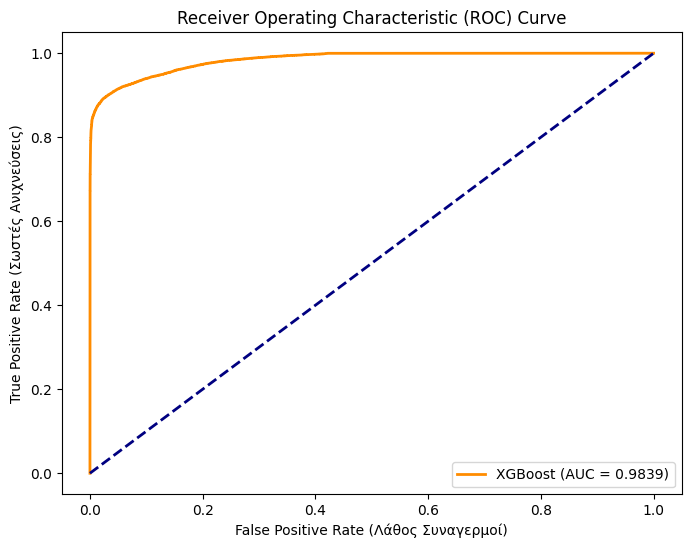

In [ ]:
print(" Αξιολόγηση μοντέλου στο Test Set (Αόρατα δεδομένα)...")
y_pred = final_xgb_model.predict(X_test)
y_proba = final_xgb_model.predict_proba(X_test)[:, 1] 

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n" + "="*40)
print("       ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ XGBOOST")
print("="*40)
print(f" Accuracy:  {acc*100:.2f}% (Συνολική ορθότητα)")
print(f" Precision: {prec:.4f} (Πόσο έγκυρος είναι ο συναγερμός επίθεσης)")
print(f" Recall:    {rec:.4f} (Πόσες από τις πραγματικές επιθέσεις βρήκαμε)")
print(f"  F1-Score:  {f1:.4f} (Ισορροπία Precision/Recall)")
print(f"  ROC AUC:   {roc_auc:.4f} (Ικανότητα διαχωρισμού normal/attack)")
print("="*40)

# Γράφημα
print("\n Δημιουργία καμπύλης ROC...")
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Λάθος Συναγερμοί)')
plt.ylabel('True Positive Rate (Σωστές Ανιχνεύσεις)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

🧠 Ξεκινάει η δοκιμή για το Νευρωνικό Δίκτυο (MLP)...
🚀 Έναρξη βελτιστοποίησης υπερπαραμέτρων MLP (5 Δοκιμές)...


  0%|          | 0/5 [00:00<?, ?it/s]/Users/antonistsipoulakos/Desktop/5g-6g-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Desktop/5g-6g-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Desktop/5g-6g-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Desktop/5g-6g-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Desktop/5g-6g-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Desktop/5g-6g-project/.venv/lib/python3.9/site-packages


🏆 Tuning Νευρωνικού Ολοκληρώθηκε!
Καλύτερες Παράμετροι: {'n_layers': 2, 'n_units_l0': 93, 'n_units_l1': 26, 'activation': 'tanh', 'alpha': 0.00020315861303646257, 'learning_rate_init': 0.0007964389232463795}
Καλύτερη Ακρίβεια (CV Score): 0.9465

⏳ Εκπαίδευση τελικού MLP Νευρωνικού...
✅ Το Νευρωνικό Δίκτυο εκπαιδεύτηκε!
⏳ Αξιολόγηση στο Test Set...

    ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ MLP (NEURAL NET)
📈 Accuracy:  86.84%
🎯 Precision: 0.8140
🔍 Recall:    0.9863
⚖️  F1-Score:  0.8919
🛡️  ROC AUC:   0.9839

🎨 Δημιουργία συγκριτικής καμπύλης ROC...


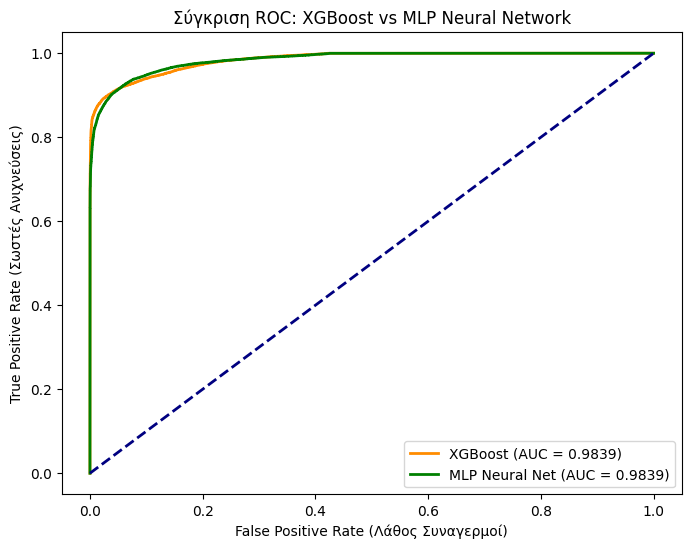

In [ ]:
import warnings
# ΑΥΤΗ Η ΕΝΤΟΛΗ ΕΙΝΑΙ Ο "ΣΙΓΑΣΤΗΡΑΣ": Κρύβει όλα τα ενοχλητικά μηνύματα (RuntimeWarnings κλπ)
warnings.filterwarnings('ignore') 

from sklearn.neural_network import MLPClassifier
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print(" Ξεκινάει η δοκιμή για το Νευρωνικό Δίκτυο (MLP)...")

def objective_mlp(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 16, 128))
        
    param = {
        'hidden_layer_sizes': tuple(layers),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter': 200, 
        'random_state': 42
    }
    
    model = MLPClassifier(**param)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    return np.mean(scores)

print(" Έναρξη βελτιστοποίησης υπερπαραμέτρων MLP (5 Δοκιμές)...")
# Κρύβουμε και τα περιττά μηνύματα της ίδιας της Optuna για να βλέπεις μόνο την ουσία
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_mlp = optuna.create_study(direction='maximize')
# Βάζουμε 5 δοκιμές για να μη σε κουράζει η αναμονή
study_mlp.optimize(objective_mlp, n_trials=5, show_progress_bar=True) 

print("\n Tuning Νευρωνικού Ολοκληρώθηκε!")
print(f"Καλύτερες Παράμετροι: {study_mlp.best_params}")
print(f"Καλύτερη Ακρίβεια (CV Score): {study_mlp.best_value:.4f}")

# ==========================================
# ΕΚΠΑΙΔΕΥΣΗ & ΑΞΙΟΛΟΓΗΣΗ ΤΕΛΙΚΟΥ ΜΟΝΤΕΛΟΥ
# ==========================================
print("\n Εκπαίδευση τελικού MLP Νευρωνικού...")

best_n_layers = study_mlp.best_params['n_layers']
best_layers = tuple([study_mlp.best_params[f'n_units_l{i}'] for i in range(best_n_layers)])

final_mlp_model = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation=study_mlp.best_params['activation'],
    alpha=study_mlp.best_params['alpha'],
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    max_iter=300,
    random_state=42
)

final_mlp_model.fit(X_train, y_train)
print(" Το Νευρωνικό Δίκτυο εκπαιδεύτηκε!")

print(" Αξιολόγηση στο Test Set...")
y_pred_mlp = final_mlp_model.predict(X_test)
y_proba_mlp = final_mlp_model.predict_proba(X_test)[:, 1] 

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp)
rec_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)
roc_auc_mlp = roc_auc_score(y_test, y_proba_mlp)

print("\n" + "="*40)
print("    ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ MLP (NEURAL NET)")
print("="*40)
print(f" Accuracy:  {acc_mlp*100:.2f}%")
print(f" Precision: {prec_mlp:.4f}")
print(f" Recall:    {rec_mlp:.4f}")
print(f"  F1-Score:  {f1_mlp:.4f}")
print(f"  ROC AUC:   {roc_auc_mlp:.4f}")
print("="*40)

# Γράφημα Συγκριτικής ROC Curve (XGBoost vs MLP)
print("\n Δημιουργία συγκριτικής καμπύλης ROC...")
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

plt.figure(figsize=(8, 6))
# Βάζουμε και το XGBoost (αφού υπάρχει ήδη στη μνήμη)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot(fpr_mlp, tpr_mlp, color='green', lw=2, label=f'MLP Neural Net (AUC = {roc_auc_mlp:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Λάθος Συναγερμοί)')
plt.ylabel('True Positive Rate (Σωστές Ανιχνεύσεις)')
plt.title('Σύγκριση ROC: XGBoost vs MLP Neural Network')
plt.legend(loc="lower right")
plt.show()